In [110]:
import json
import numpy as np
from PIL import Image
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

from dataset_parameters import *

### Import Dataset And Labels

In [2]:
datas, speeds = [], []

with open("dataset/labels/labels.json", "r") as lab_file:
    file = json.load(lab_file)
    labels = list(zip(file.keys(), file.values()))

    import_loop = tqdm(labels, total = len(labels), leave = True)
    
    for lab in import_loop:
        if lab[1]["class"] == 1:
            img = Image.open(DATASET_IMAGES_PATH + lab[0])
            datas.append(np.array(img))
            speeds.append(lab[1]["speed"])

print(f"Dataset size: {len(datas)}")

# SHUFFLE THE ELEMENTS BUT KEEP THE CORRESPONDENCES
shuffled = list(zip(datas, speeds))

random.shuffle(shuffled)

datas_shuffle, speeds_shuffle = zip(*shuffled)

# CONVERT THE RESULT TO LISTS
datas = list(datas_shuffle)
speeds = list(speeds_shuffle)

100%|██████████| 19993/19993 [05:06<00:00, 65.29it/s]


Dataset size: 9998


In [3]:
# TRAIN/TEST DATASET SPLIT
ds_size = len(datas)
split = int((ds_size / 100) * 70)

datas_train, speeds_train = datas[:split], speeds[:split]
datas_test, speeds_test = datas[split:], speeds[split:]

print(f"Train set size: {len(datas_train)}, Test set size: {len(datas_test)}")
print(f"Images dimensions: {np.size(datas_train[0])}")

Train set size: 6998, Test set size: 3000
Images dimensions: 4946112


### Velocity Estimation Network

In [111]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchmetrics.regression import SymmetricMeanAbsolutePercentageError

from custom_datasets import SirenRegressionDataset

In [112]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
MODEL_PATH = 'models/velocity_regression_model.pth'
BS_TRAIN, BS_TEST = 32, 1
LR = 0.001
EPOCHS = 20
SMAPE = SymmetricMeanAbsolutePercentageError() # SYMMETRIC MEAN ABSOLUTE PERCENTAGE ERROR

In [113]:
# DATASETS
train_dataset = SirenRegressionDataset(datas_train, speeds_train)
test_dataset = SirenRegressionDataset(datas_test, speeds_test)

# DATALOADERS
train_dataloader = DataLoader(train_dataset, batch_size = BS_TRAIN, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = BS_TEST, shuffle = True)

  0%|          | 0/219 [03:55<?, ?it/s]


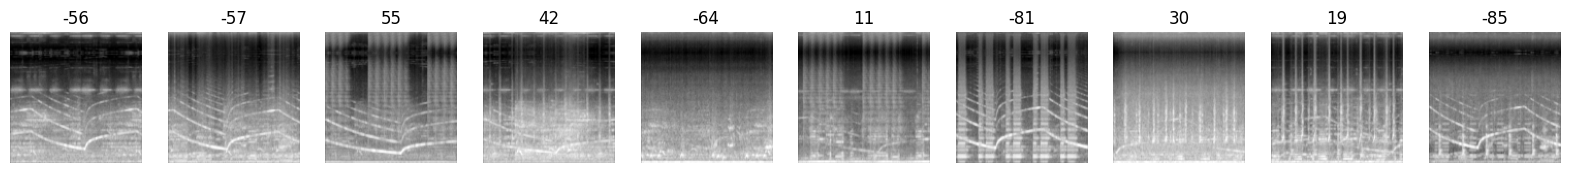

In [114]:
to_pil = transforms.ToPILImage()
figure = plt.figure(figsize=(20,20))
cols, rows = 10, 1

for i in range(1, rows + 1):
    for j in range(0, cols):
        image = test_dataset[i+j][0]
        label = test_dataset[i+j][1]
        figure.add_subplot(rows, cols, i + j)
        plt.axis("off")
        plt.title(label)
        plt.imshow(to_pil(image), cmap="gray")
plt.show()

In [115]:
class VelocityRegressionNN(nn.Module):
    def __init__(self):
        super(VelocityRegressionNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)

        self.bn1 = nn.BatchNorm2d(16)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(64)
        
        self.fc1 = nn.Linear(128 * 128, 512)
        self.fc2 = nn.Linear(512, 1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)
        return x

In [124]:
def train(model : VelocityRegressionNN, optimizer : optim, train_loader : DataLoader, test_loader : DataLoader) -> None:
    loss = nn.MSELoss()
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size = 5, gamma = 0.5)

    # Training Loop
    for epoch in range(EPOCHS):

        model.train()

        running_loss = 0.0 # CUMULATIVE LOSS OF THE CURRENT EPOCH
        train_pred = [] # TRAINING PREDICTIONS OF THE CURRENT EPOCH
        train_gt  = [] # TRAINING GROUND TRUTH OF THE CURRENT EPOCH

        batch_loop = tqdm(enumerate(train_loader), total = len(train_loader), leave = True) # BATCH OF TRAINING DATA
        
        for batch, (images, velocities) in batch_loop:

            images = images.to(DEVICE)
            velocities = velocities.to(DEVICE).unsqueeze(-1).float()
            
            model.zero_grad()
            pred = model(images)
            
            l = loss(pred, velocities)
            l.backward()
            optimizer.step()

            running_loss += l.item() / BS_TRAIN
            train_pred.append(torch.flatten(pred))
            train_gt.append(torch.flatten(velocities))
        
        with torch.no_grad():
            # STATISTICS
            y_true, y_pred = torch.cat(train_gt), torch.cat(train_pred)
            print(f'EPOCH [{epoch + 1}/{EPOCHS}], TRAIN LOSS: {running_loss / len(train_loader):.4f}, TRAIN MAPE: {SMAPE(y_pred, y_true)}')

            # MODEL BACKUP
            torch.save(model.state_dict(), MODEL_PATH)
            
        scheduler.step()
        
        model.eval()

        with torch.no_grad():
            val_loss = 0.0 # VALIDATION LOSS OF THE CURRENT EPOCH
            test_pred = [] # TESTING PREDICTIONS OF THE CURRENT EPOCH
            test_gt  = [] # TESTING GROUND TRUTH OF THE CURRENT EPOCH
            
            for batch, (images, velocities) in enumerate(test_loader):
                images = images.to(DEVICE)
                velocities = velocities.to(DEVICE).unsqueeze(-1).float()

                pred = model(images)
                l = loss(pred, velocities)

                val_loss += l.item()
                test_pred.append(torch.flatten(pred))
                test_gt.append(torch.flatten(velocities))
                
                if batch == 500 // BS_TEST : break # TEST ONLY ON 500 IMAGES EVERY EPOCH

            # STATISTICS
            y_true, y_pred = torch.cat(test_gt), torch.cat(test_pred)
            print(f'\tVALIDATION LOSS: {val_loss / 500:.4f}, VALIDATION SMAPE: {SMAPE(y_pred, y_true):.4f}')

In [125]:
# INITIALIZE THE MODEL
model = VelocityRegressionNN().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr = LR)

### Training

In [126]:
# TRAIN THE MODEL
train(model, optimizer, train_dataloader, test_dataloader)

100%|██████████| 219/219 [02:30<00:00,  1.45it/s]


EPOCH [1/20], TRAIN LOSS: 43.0501, TRAIN MAPE: 0.8690953850746155
	VALIDATION LOSS: 1043.3599, VALIDATION MAPE: 0.7274


100%|██████████| 219/219 [02:44<00:00,  1.33it/s]


EPOCH [2/20], TRAIN LOSS: 26.0357, TRAIN MAPE: 0.6430289149284363
	VALIDATION LOSS: 758.0512, VALIDATION MAPE: 0.5888


100%|██████████| 219/219 [02:36<00:00,  1.40it/s]


...

EPOCH [18/20], TRAIN LOSS: 5.3975, TRAIN MAPE: 0.3170407712459564
	VALIDATION LOSS: 298.1400, VALIDATION MAPE: 0.3284


100%|██████████| 219/219 [02:59<00:00,  1.22it/s]


EPOCH [19/20], TRAIN LOSS: 5.2546, TRAIN MAPE: 0.31134164333343506
	VALIDATION LOSS: 375.6011, VALIDATION MAPE: 0.3687


100%|██████████| 219/219 [03:07<00:00,  1.17it/s]


EPOCH [20/20], TRAIN LOSS: 5.1093, TRAIN MAPE: 0.30990004539489746
	VALIDATION LOSS: 424.8094, VALIDATION MAPE: 0.3905


### Results

C:\Users\andre\AppData\Local\Temp\ipykernel_13776\2646503768.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/velocity_regression

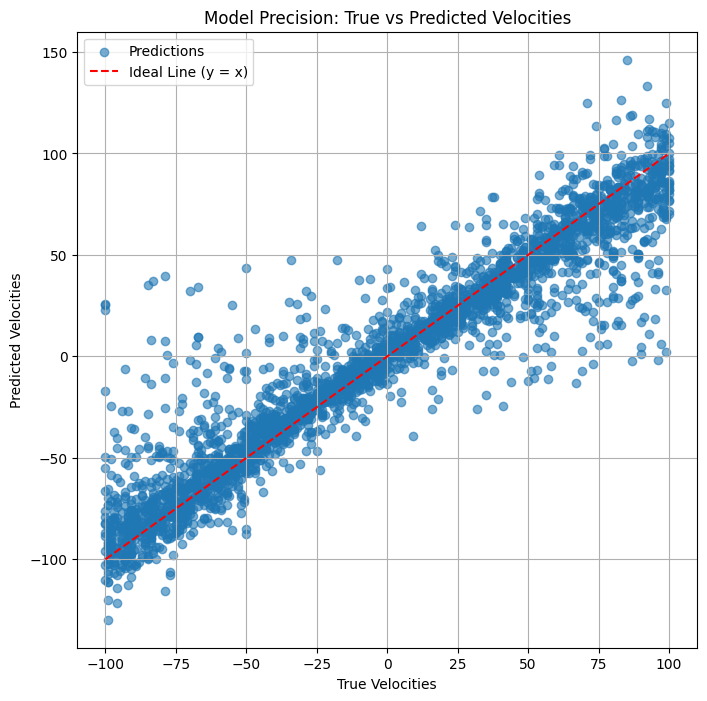

In [127]:
# Collect predictions and true velocities
true_velocities = []
predicted_velocities = []
model.load_state_dict(torch.load("models/velocity_regression_model.pth"))
model.eval()
with torch.no_grad():
    for images, velocities in test_dataloader:
        images = images.float()
        velocities = velocities.float().view(-1, 1)
        outputs = model(images)
        true_velocities.extend(velocities.numpy())
        predicted_velocities.extend(outputs.numpy())

# Create the scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(true_velocities, predicted_velocities, alpha=0.6, label="Predictions")
plt.plot([min(true_velocities), max(true_velocities)], 
         [min(true_velocities), max(true_velocities)], 
         color="red", linestyle="--", label="Ideal Line (y = x)")
plt.xlabel("True Velocities")
plt.ylabel("Predicted Velocities")
plt.title("Model Precision: True vs Predicted Velocities")
plt.legend()
plt.grid(True)
plt.show()